In [ ]:
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import matplotlib

from alter_surf.hamiltonian_DLKK import H_DLKK_3D_MF, Spin_operator, Sublattice_operator, points_BZ, Econst_DLKK_3D_MF
from alter_surf.mean_field import hartree_fock, total_energy



In [64]:
Hparam0 = dict(len_z=40,delta=0.8, tp=0.5, tz=1, U=8, filling=0.5+1e-2, PBC= False)
MF_parameters = dict(n_steps=60, Lq=40, tol_mdiff=1e-4,mixing_proportion=0.1,adjust_learning_rate=False)

initial_parameters = dict(initial_mAF=(-1)**np.arange(Hparam0['len_z'])/4,
                          initial_mF =np.ones(Hparam0['len_z']) * 0,
                          initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)


mAFs, mFs, ns, fermi_energys = hartree_fock(Hparam0.copy(),initial_parameters, **MF_parameters)

Hparam = dict(**Hparam0, mAF=mAFs[-1],mF=mFs[-1],ns=ns[-1],mu=fermi_energys[-1])



Avg:0.00, Stag. avg:0.82, diff: 0.000008:  18%|█▊        | 11/60 [01:50<08:11, 10.04s/it]


Checking the convergence of the MF simualtion 

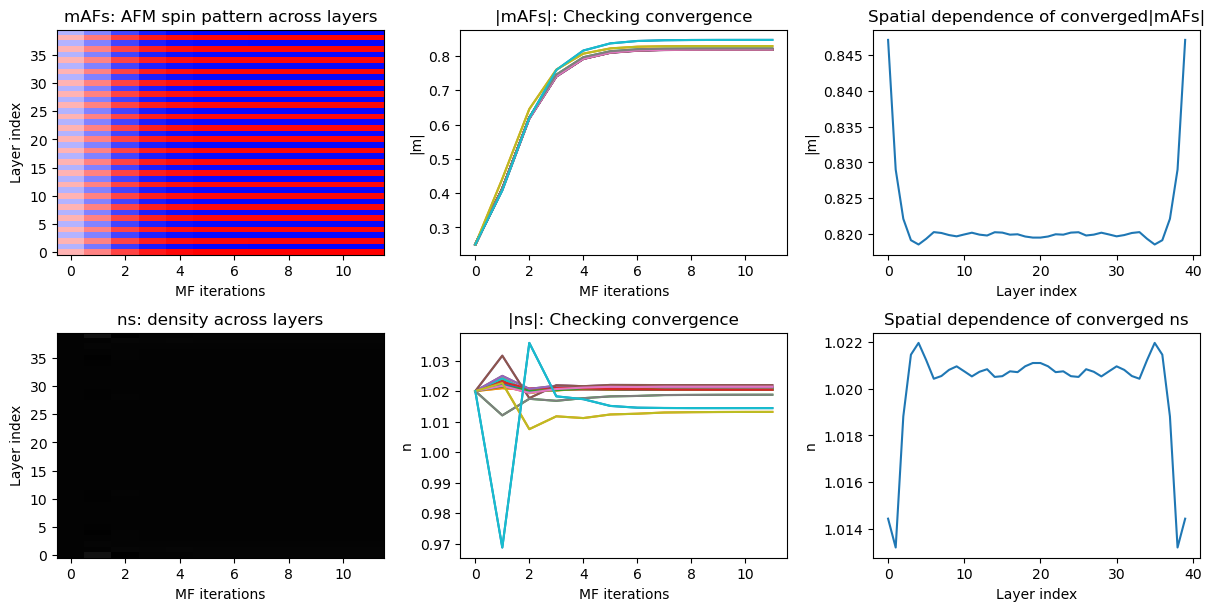

In [65]:
fig, axs = plt.subplots(2,3, figsize=(12,6), constrained_layout=True)

#plot the AF magnatization 
axs[0,0].set_title('mAFs: AFM spin pattern across layers')
axs[0,0].set_xlabel('MF iterations')
axs[0,0].set_ylabel('Layer index')
axs[0,0].imshow(mAFs.T, aspect='auto', cmap='bwr',origin='lower', vmin=-mAFs.max(), vmax=mAFs.max())

axs[0,1].set_title('|mAFs|: Checking convergence')
axs[0,1].set_xlabel('MF iterations')
axs[0,1].set_ylabel('|m|')
axs[0,1].plot(np.abs(mAFs))

axs[0,2].set_title('Spatial dependence of converged|mAFs|')
axs[0,2].set_xlabel('Layer index')
axs[0,2].set_ylabel('|m|')
axs[0,2].plot(np.abs(mAFs[-1]))

#plot the density 
axs[1,0].set_title('ns: density across layers')
axs[1,0].set_xlabel('MF iterations')
axs[1,0].set_ylabel('Layer index')
axs[1,0].imshow(ns.T, aspect='auto', cmap='Greys',origin='lower', vmin=0, vmax=ns.max())

axs[1,1].set_title('|ns|: Checking convergence')
axs[1,1].set_xlabel('MF iterations')
axs[1,1].set_ylabel('n')
axs[1,1].plot(ns)

axs[1,2].set_title('Spatial dependence of converged ns')
axs[1,2].set_xlabel('Layer index')
axs[1,2].set_ylabel('n')
axs[1,2].plot(ns[-1])




Now we need to check that it is acutally the lowest state in energy. We compare to other solutions of the MF equations

1) Paramagnetic/ non-magnetic (PM)
2) A (pi,pi,0) AFM (AFM0)
2) Weak AM solution: very small magnetization (AM')
3) FM solution (FM)

In [ ]:
labels = ['AM','NM','AFM0', "AM'",'FM']

initial_param_NM  = dict(initial_mAF=np.zeros(Hparam0['len_z']),
                         initial_mF =np.zeros(Hparam0['len_z']),
                         initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)
initial_param_AFM0 = dict(initial_mAF=np.ones(Hparam0['len_z'])/4,
                         initial_mF =np.zeros(Hparam0['len_z']),
                         initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)
initial_param_AMp = dict(initial_mAF=(-1)**np.arange(Hparam0['len_z'])/100,
                         initial_mF =np.zeros(Hparam0['len_z']),
                         initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)
initial_param_FM  = dict(initial_mAF=np.zeros(Hparam0['len_z']),
                         initial_mF =np.ones(Hparam0['len_z'])/4,
                         initial_n=Hparam0['filling']*np.ones(Hparam0['len_z'])*2)

initial_params = [initial_parameters, initial_param_NM, initial_param_AFM0, initial_param_AMp, initial_param_FM]

Hparams = [Hparam.copy()] #add the rest later.

#Solve each trial state
for j in range(1,len(initial_params)):
    mAFs, mFs, ns, fermi_energys = hartree_fock(Hparam0.copy(),initial_params[j], **MF_parameters)
    Hparam_trial = dict(**Hparam0, mAF=mAFs[-1],mF=mFs[-1],ns=ns[-1])
    Hparams.append(Hparam_trial.copy())






Avg:0.00, Stag. avg:0.00, diff: 0.000000:   3%|▎         | 2/60 [00:09<04:31,  4.68s/it]


Lowest energy state:  AM


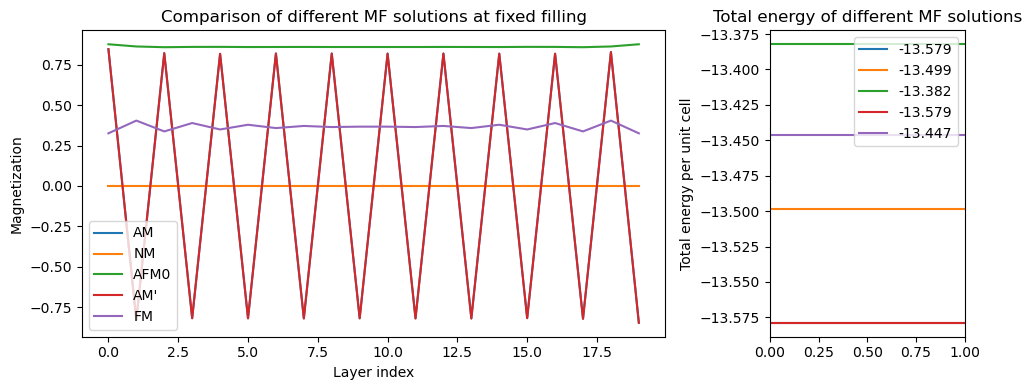

In [ ]:
fix,axs = plt.subplots(1,2, figsize=(10,4), gridspec_kw={'width_ratios': [3, 1]})



etots = []

for j in range(len(Hparams)):
    #plot state
    if Hparams[j]['mAF'].max() > Hparams[j]['mF'].max():
        axs[0].plot(Hparams[j]['mAF'],label=labels[j])
    else:
        axs[0].plot(Hparams[j]['mF'],label=labels[j])
    
    #compute total energy
    e_tot = total_energy(Hparams[j], Lq=MF_parameters['Lq'])
    etots.append(e_tot)

    axs[1].plot([0,1], np.ones(2)*e_tot, label=np.round(e_tot, 3))

axs[0].set_xlabel('Layer index')
axs[0].set_ylabel('Magnetization')
axs[0].set_title('Comparison of different MF solutions at fixed filling')
axs[0].legend()

axs[1].set_xlim(0,1)
axs[1].set_ylabel('Total energy per unit cell')
axs[1].set_title('Total energy of different MF solutions')
axs[1].legend()

plt.tight_layout()

print('Lowest energy state: ', labels[np.argmin(etots)])

# Properties of the state

## Checking properties of the bands

In [151]:
from blochK.plotting import plot_FS, plot_bandstruc
from blochK.observable import eigs_H,exp_value_O,conductivity
from blochK.methods_basic import sample_reducedBZ

from alter_surf.utils3D import projector2layer

/Users/valentin/Documents/1_Promotion/Altermagnetism/Surface/alter_surf/src/blochK/plotting.py:65: UserWarning: No contour levels were found within the data range.
  FS0 = ax.contour(xs,ys,es[iband],[0],alpha=0)


0.5102


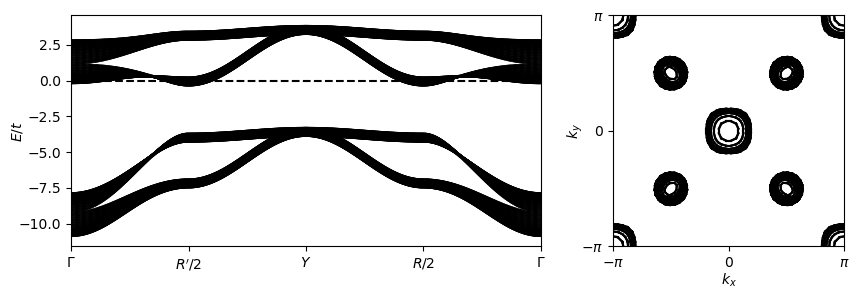

In [66]:

param = Hparam.copy()

labels = ["R'",'\Gamma','R',"X",'\Gamma']
labels = ['\Gamma',"R'/2","Y","R/2",'\Gamma']
pathBZ = np.array([points_BZ[x] for x in labels])
labels = ['$'+l+'$' for l in labels]

coloring_operator = np.kron(np.ones(param['len_z']), Spin_operator)

cmap = 'bwr'

fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
plot_bandstruc(ax,H_DLKK_3D_MF,param=param,points_path=pathBZ,labels_points_path=labels,coloring_operator=coloring_operator,cmap=cmap)
plot_FS(ax1,H_DLKK_3D_MF,param=param,coloring_operator=coloring_operator,cmap=cmap,Lq=50,print_filling=True)


In [67]:
Lq = MF_parameters['Lq'] #number of k-points in each direction
Hamiltonian_fct = H_DLKK_3D_MF


# Define the parameters for the Hamiltonian
param = Hparam
# Define the k-point grid
kxs = np.linspace(-pi,pi,Lq)
kys = np.linspace(-pi,pi,Lq)
xs,ys = np.meshgrid(kxs,kys)
ks = np.moveaxis([xs,ys],0,-1)
#Diagonalize Hamiltonian
es,psis = eigs_H(xs,ys,Hamiltonian_fct,param)

def plot_spectral_density(ax,spectral_density,cmap='bwr',title_plot='',show_xlabel=True,show_ylabel=True,vmax='',vmin=''):
    """Plots colored spin spectral density on ax,

    cmap: a matplotlib colormap
    title_plot: title of the plot if given
    vmax: maximum value for color scaling
    """
    if title_plot!='':
         ax.set_title(title_plot,fontsize=6)
    ax.set_aspect('equal')
    if show_xlabel:
        ax.set_xlabel('$k_x$',labelpad=1)
        ax.set_xticks([-pi,0,pi])
        ax.set_xticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_xticklabels([])
    if show_ylabel:
        ax.set_ylabel('$k_y$',labelpad=-2.5)
        ax.set_yticks([-pi,0,pi])
        ax.set_yticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_yticklabels([])
    ax.set_xlim(-pi,pi)
    ax.set_ylim(-pi,pi)
    #--------------
    if vmax == '':
        vmax = np.abs(spectral_density).max()
    if vmin == '':
        vmin = -vmax
    im = ax.imshow(spectral_density,extent=(-pi,pi,-pi,pi),origin='lower',cmap=cmap,vmin=vmin,vmax=vmax)
    return im




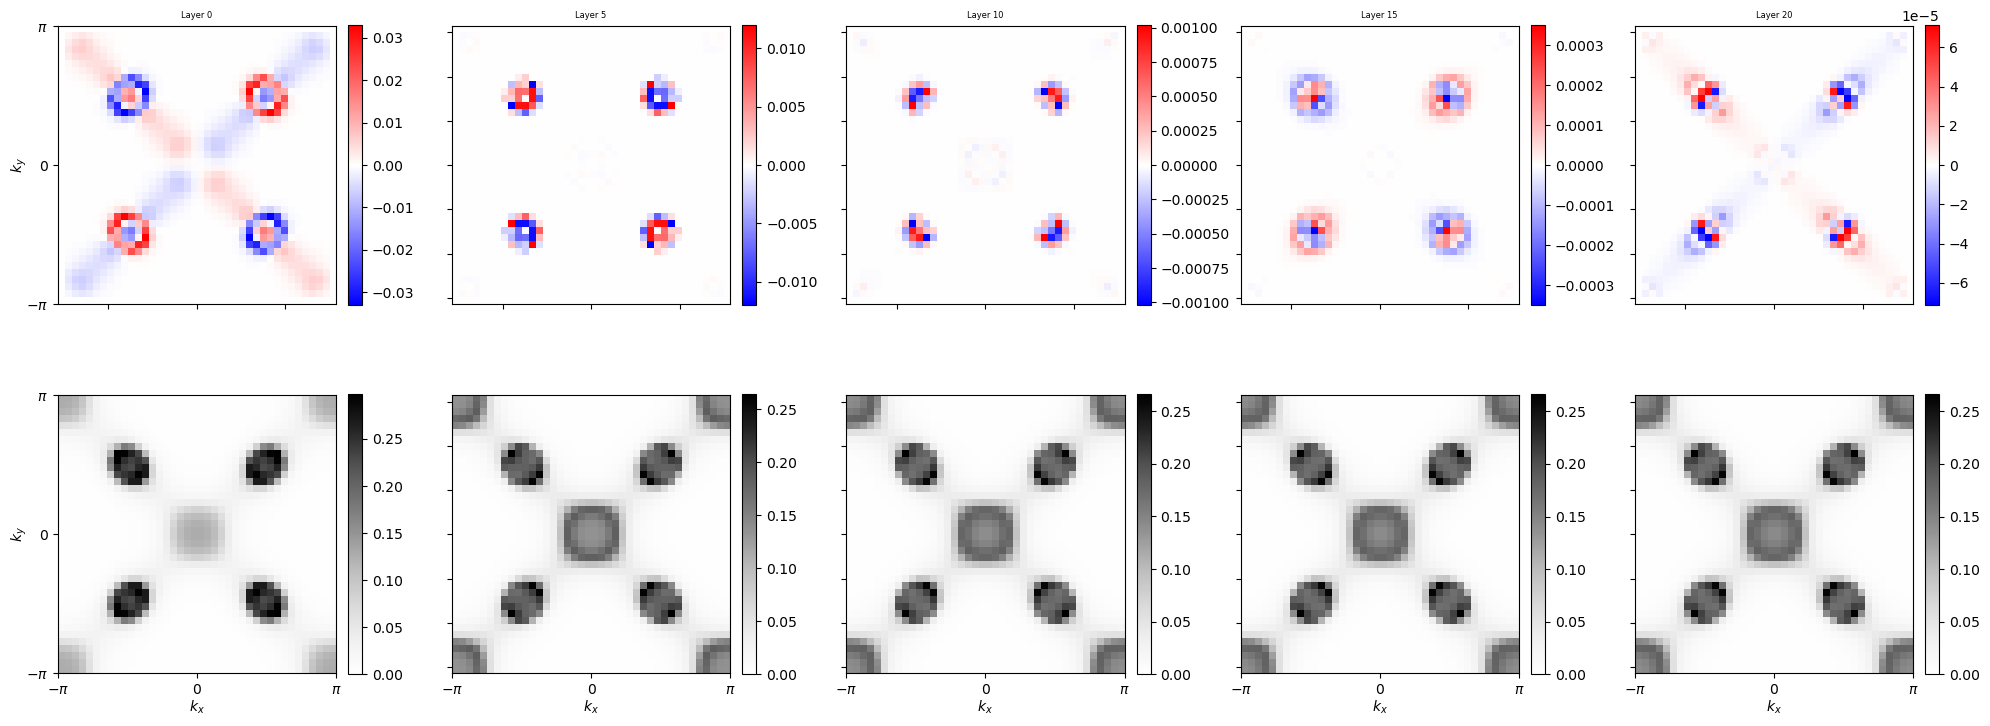

In [69]:
Gamma = 10e-2
len_z = param['len_z']
#layers = [0,len_z//6,len_z//3,len_z//2]
layers = np.linspace(0,len_z//2,5,dtype=int)


#Plot
fig,axs = plt.subplots(2,len(layers),figsize=(4*len(layers),8))

for ax_column,layer in zip(axs.T,layers):
    proj_2layers = projector2layer(layer,len_z=len_z)+projector2layer(layer+1,len_z=len_z)
    coloring_operator = np.kron(proj_2layers,Spin_operator) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spectral_density_spin = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z

    #compute spectral density
    Os = exp_value_O(np.kron(proj_2layers,np.ones(4)),psis) #.shape=(n,y,x)
    spectral_density0 = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z

    
    vmax_spin = np.abs(spectral_density_spin).max()
    vmax0 = np.abs(spectral_density0).max()

    imT = plot_spectral_density(ax_column[0],spectral_density_spin,title_plot='Layer '+str(layer),show_ylabel=(layer==0),show_xlabel=False,vmax=vmax_spin)
    imB = plot_spectral_density(ax_column[1],spectral_density0,show_ylabel=(layer==0),show_xlabel=True,vmax=vmax0,vmin=0,cmap='Greys')
    
    #colorbars for each plot
    plt.colorbar(imT,ax=ax_column[0],fraction=0.046,pad=0.04)
    plt.colorbar(imB,ax=ax_column[1],fraction=0.046,pad=0.04)    


# plt.colorbar(imT,ax=axs[0,-1],fraction=0.046,pad=0.04)
# plt.colorbar(imB,ax=axs[1,-1],fraction=0.046,pad=0.04)

plt.tight_layout()


## Checking the spectral density along a 1D path

In [103]:
Lq = 500 #number of k-points in each direction
Gamma = 1.e-3


# Define the k-point grid
kxs = np.linspace(0,pi/2,Lq)
kys = kxs
#Diagonalize Hamiltonian
es,psis = eigs_H(kxs,kys,Hamiltonian_fct,param)

#compute spectral density
#layers = np.arange(0,param['len_z']//2,1,dtype=int) #half the layers
layers = np.arange(0,param['len_z']-1,1,dtype=int) #all layers
spin_spec_dens = []
spec_dens = []
for layer in layers:
    proj_2layers = projector2layer(layer,len_z=param['len_z'])+projector2layer(layer+1,len_z=param['len_z'])
    coloring_operator = np.kron(proj_2layers,Spin_operator) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spin_spec_dens.append(np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/param['len_z'])

    #computespectral density
    Os = exp_value_O(np.kron(proj_2layers,np.ones(4)),psis) #.shape=(n,y,x)
    spec_dens.append(np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/param['len_z'])

spin_spec_dens = np.array(spin_spec_dens) #layers, ks
spec_dens = np.array(spec_dens)


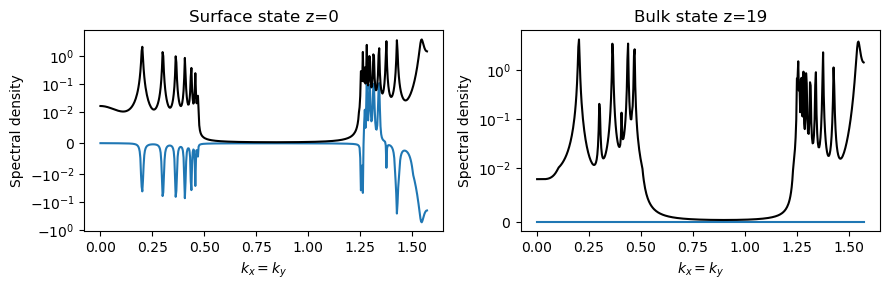

In [107]:
fig,axs = plt.subplots(1,2,figsize=(9,3))

layer = 0
axs[0].set_title('Surface state z=0')
axs[0].plot(kxs,spin_spec_dens[layer],'-')
axs[0].plot(kxs,spec_dens[layer],'k-')
axs[0].set_yscale('symlog',linthresh=1e-2)

layer = layers[-1]//2 if layers[-1]==Hparam['len_z']-2 else layers[-1]
axs[1].set_title('Bulk state z='+str(layer))
axs[1].plot(kxs,spin_spec_dens[layer],'-')
axs[1].plot(kxs,spec_dens[layer],'k-')
axs[1].set_yscale('symlog',linthresh=1e-2)

axs[0].set_xlabel('$k_x=k_y$')
axs[1].set_xlabel('$k_x=k_y$')
axs[0].set_ylabel('Spectral density')
axs[1].set_ylabel('Spectral density')

plt.tight_layout()


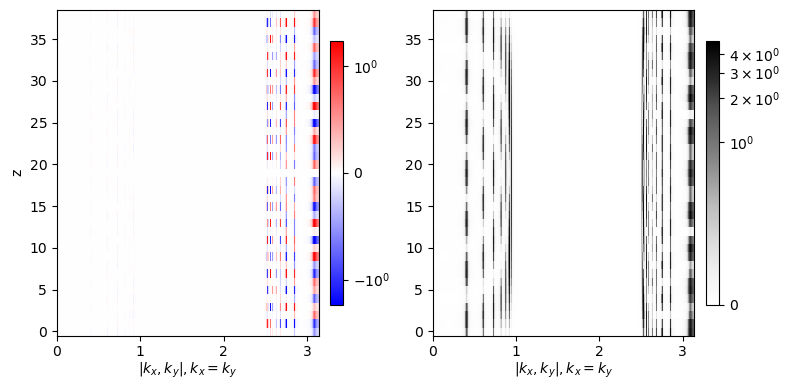

In [89]:
fig,[ax1,ax2] = plt.subplots(1,2,figsize=(8,4))

ax1.set_xlabel('$|k_x,k_y|, k_x=k_y$',labelpad=1)
ax2.set_xlabel('$|k_x,k_y|, k_x=k_y$',labelpad=1)
ax1.set_ylabel('z')

vmax = np.abs(spin_spec_dens).max()
#We use a symlog scale
#im1 = ax1.imshow(spin_spec_dens,extent=(0,pi,0,layers[-1]),origin='lower',cmap='bwr',vmin=-vmax,vmax=vmax,aspect='auto')
im1 = ax1.imshow(spin_spec_dens,extent=(0,pi,-0.5,layers[-1]+0.5),origin='lower',cmap='bwr',aspect='auto',interpolation='none',norm=matplotlib.colors.SymLogNorm(linthresh=1, linscale=1,vmin=-vmax, vmax=vmax, base=10))
#im2 = ax2.imshow(spec_dens,extent=(0,pi,0,layers[-1]),origin='lower',cmap='Greys',vmin=0,vmax=spec_dens.max(),aspect='auto')
im2 = ax2.imshow(spec_dens,extent=(0,pi,-0.5,layers[-1]+0.5),origin='lower',cmap='Greys',aspect='auto',interpolation='none',norm=matplotlib.colors.SymLogNorm(linthresh=1, linscale=1,vmin=0,vmax=spec_dens.max(), base=10))

plt.colorbar(im1,ax=ax1,fraction=0.046,pad=0.04)
plt.colorbar(im2,ax=ax2,fraction=0.046,pad=0.04)

plt.tight_layout()

The integrated spectral density along the path $(0,0)$ to $(\pi,\pi)$

$A_\sigma(z) = \int_{k=(0,0)}^{k=\pi/2(1,1)} A_\sigma(z,k)$

and as function of distance from the bulk, i.e.

$A_\sigma(d) = \int_{z'=0}^{z'=d} d z' \int_{k=(0,0)}^{k=\pi/2(1,1)} A_\sigma(L_z/2+z',k) $

Text(0.5, 0, 'depth d')

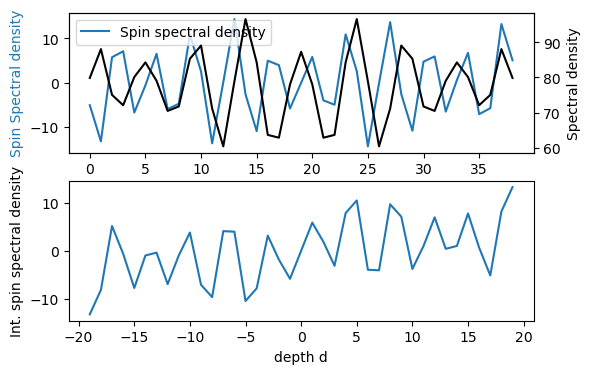

In [152]:
#integration along k
intk_spin_spec_dens = np.sum(spin_spec_dens,axis=1)
intk_spec_dens = np.sum(spec_dens,axis=1)

#integration from the middle to the surface
int_spin_spec_dens = np.concatenate((np.cumsum(intk_spin_spec_dens[layers[-1]//2::-1])[::-1],
                                     np.cumsum(intk_spin_spec_dens[layers[-1]//2::]   )))
# int_spec_dens = np.cumsum(np.sum(spec_dens,axis=1),axis=0)

fig,axs = plt.subplots(2,1,figsize=(6,4))
axs[0].plot(intk_spin_spec_dens,'-',label='Spin spectral density')
axs2 = axs[0].twinx()
axs2.plot(intk_spec_dens,'k-',label='spectral density')
axs[0].set_xlabel('Layer')
axs[0].set_ylabel('Spin Spectral density', color='C0')
axs2.set_ylabel('Spectral density', color='k')
axs[0].legend()

xs = np.concatenate((np.arange(-layers[-1]//2,1,1),np.arange(0,layers[-1]//2+1)))
axs[1].plot(xs,int_spin_spec_dens,'-',label='Integrated spectral density from middle to surface')
axs[1].set_ylabel('Int. spin spectral density')
axs[1].set_xlabel('depth d')

In [153]:
#setting parameters
Lq = 40 #number of k-points in each direction


# Calculate spin conductivity
Gamma = 2e-1
kmesh_BZ = sample_reducedBZ(Lq) #you need to work with the right BZ: No translation symmetry breaking -> folded BZ
layer = 0
proj_2layers = np.sum([projector2layer(layer+j,len_z=param['len_z']) for j in range(4)],axis=0)
Spin_op_layer = np.kron(proj_2layers,Spin_operator) #projected spin_operator
spin_cond = conductivity(Hamiltonian_fct,Hparam=param,Gamma=Gamma,operator=Spin_op_layer,kmesh_BZ=kmesh_BZ,optimize='path')
cond = conductivity(Hamiltonian_fct,Hparam=param,Gamma=Gamma,operator=np.kron(proj_2layers,np.ones_like(Spin_operator)),kmesh_BZ=kmesh_BZ,optimize='path')
print('spin_cond: \t', spin_cond)
print('cond: \t', cond)
print('spin splitter angle: \t', 2*np.arctan(spin_cond[0,0]/cond[0,0]) *180/pi)


spin_cond: 	 [[ 4.39130774e-02 -1.53443511e-18]
 [-1.36202390e-18 -4.39130774e-02]]
cond: 	 [[9.82915757e-01 1.20855248e-19]
 [3.48239368e-18 9.82915757e-01]]
spin splitter angle: 	 5.11612924547754


In [178]:
layers = np.arange(0,len_z,2,dtype=int)
spin_cond00 = []
cond00 = []

for layer in layers:
    proj_2layers = projector2layer(layer,len_z=param['len_z'])+projector2layer(layer+1,len_z=param['len_z'])
    Spin_op_layer = np.kron(proj_2layers,Spin_operator) #projected spin_operator
    spin_cond = conductivity(Hamiltonian_fct,Hparam=param,Gamma=Gamma,operator=Spin_op_layer,kmesh_BZ=kmesh_BZ,optimize='path') 
    cond = conductivity(Hamiltonian_fct,Hparam=param,Gamma=Gamma,operator=np.kron(proj_2layers,np.ones(4)),kmesh_BZ=kmesh_BZ,optimize='path')
    spin_cond00.append(spin_cond[0,0])
    cond00.append(cond[0,0])

In [ ]:
def conductivity_orbital_resolved(Hamiltonian_fct,Hparam=dict(),Gamma=1e-2,energy=0,kmesh_BZ=None,optimize='path'):
    """
    Evalutes the conductivity of Hamiltonian_fct with 'Hparam' in the diagonal bloch basis,
    i.e. the current operator j_iab(k) = O_a * v_ab(k) is not contracted over a (localH index). Only valid for O diagonal. This is much faster than calling conductivity several times.
    Parameters:
    'Hamiltonian_fct': function that returns the Hamiltonian in k-space
    'Hparam': parameters for the Hamiltonian function
    'Gamma':  spectral broadening
    'energy': addtional energy at which the conductivity is evaluated. Default is 0 (Fermi level)
    'Lq': number of k-points in the q-direction
    'kmesh_BZ': the k-points of the Brillouin zone. If None, square BZ is sampled with 100x100 points
    'optimize': optimization strategy for the computation, see numpy.einsum documentation, for a new problem use 'find_path' first, store it in function and use 'path'
    Returns:
    conductivity tensor .shape=(localH,2,2) (basis of H, n1 direction, n2 direction)
    """
    #sampling the BZ
    if kmesh_BZ is None:
        Lq = 100
        kmesh_BZ = sample_BZ(Lq)
    else:
        Lq = kmesh_BZ.shape[1]
    ks = kmesh_BZ #ks.shape=(2,k,q)

    #compute the hamiltonian, eigenvalues and eigenstates
    Hk = Hamiltonian_fct(*ks,**Hparam) #.shape = (localH,localH,k,q)
    es,psi = eigs_H(*ks,Hamiltonian_fct,Hparam) #.shape=(band,k,q,localH)
    
    #compute the derivatives of Hk along unit vectors of BZ
    dk = np.linalg.norm(np.abs(ks[:,0,1]-ks[:,0,0]),axis=0) 
    v1 = -(np.roll(Hk,1,axis=2)-np.roll(Hk,-1,axis=2))/dk/2 #along first axis
    v2 = -(np.roll(Hk,1,axis=3)-np.roll(Hk,-1,axis=3))/dk/2 #along second axis
    v = np.array([v1,v2]) #.shape = (2,localH,localH,k,q)
        
    Greenfct = Gamma/((es-energy)**2+Gamma**2) #.shape = (band,Lq,Lq)

    #compute the product of all these quantities
    #contracting of many indices might be costly, therefore use preoptimized path or 'greedy'
    if optimize=='path':
        opt_path = ['einsum_path', (0, 6), (1, 5), (1, 5), (0, 4), (1, 2), (0, 2), (0, 1)]
        sigma = np.einsum('nkqa,iabkq,mkqb,mkqc,jcdkq,nkqd,nkq,mkq->aij',np.conjugate(psi),v,psi,np.conjugate(psi),v,psi,Greenfct,Greenfct,optimize=opt_path)
    elif optimize=='find_path': #returns the optimal path, no results!
        opt_path = np.einsum_path('nkqa,iabkq,mkqb,mkqc,jcdkq,nkqd,nkq,mkq->aij',np.conjugate(psi),v,psi,np.conjugate(psi),v,psi,Greenfct,Greenfct, optimize='optimal')[0]
        print('Optimal contraction path found:',opt_path)
        return opt_path
    elif optimize=='greedy':
        sigma = np.einsum('nkqa,iabkq,mkqb,mkqc,jcdkq,nkqd,nkq,mkq->aij',np.conjugate(psi),v,psi,np.conjugate(psi),v,psi,Greenfct,Greenfct,optimize='greedy')
    else:
        sigma = np.einsum('nkqa,iabkq,mkqb,mkqc,jcdkq,nkqd,nkq,mkq->aij',np.conjugate(psi),v,psi,np.conjugate(psi),v,psi,Greenfct,Greenfct)
    
    
    return np.real(sigma)/Lq**2 /np.pi

ys = conductivity_orbital_resolved(Hamiltonian_fct,Hparam=param,Gamma=Gamma,kmesh_BZ=kmesh_BZ,optimize='path')

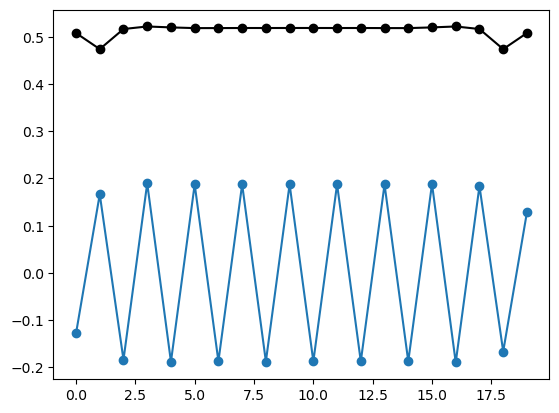

In [ ]:
#need to test the reshape stuff:
print(ys.shape)

test = np.reshape(ys, (param['len_z'],2,2,2,2)) #.shape=(layer,spin,sublattice,x,y)

n_layers = 2 #number of layers to sum over
test = test.reshape(n_layers,-1,2,2,2,2) #.shape=(n_layers,layer/n_layers,spin,sublattice,x,y)
#sum over layers, sublattice, select xx component
test_xx = np.sum(test[:,:,:,:,0,0],axis=(0,3)) #.shape=(layer/n_layers,spin)

plt.plot(test_xx[:,0]-test_xx[:,1],'o-')
plt.plot(test_xx[:,0]+test_xx[:,1],'ko-')

Text(0, 0.5, 'Conductivity')

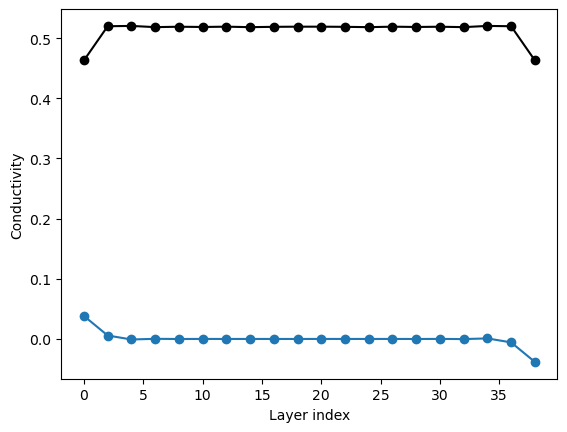

In [179]:
plt.plot(layers,spin_cond00,'o-')
plt.plot(layers,cond00,'ko-')
plt.xlabel('Layer index')
plt.ylabel('Conductivity')

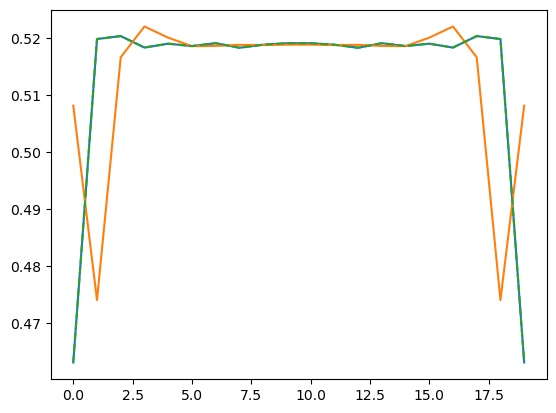

In [192]:
plt.plot(cond00)
plt.plot(test_xx[:,0]+test_xx[:,1])
plt.plot(test_cond00,linestyle='--')

In [190]:
test_spin_cond00 = []
test_cond00 = []


for layer in layers:
    proj_2layers = projector2layer(layer,len_z=param['len_z'])+projector2layer(layer+1,len_z=param['len_z'])
    Spin_op_layer = np.kron(proj_2layers,Spin_operator) #projected spin_operator
    test_spin_cond00.append(np.sum(Spin_op_layer*ys[:,0,0]))
    test_cond00.append(np.sum(np.kron(proj_2layers,np.ones(4))*ys[:,0,0]))

In [189]:
ys.shape

(160, 2, 2)